# Swin Transformer from Scratch — Colab CIFAR-10 Version with Visualization and Metrics

This notebook is configured for Google Colab using **CIFAR-10**, which downloads directly through `torchvision.datasets.CIFAR10`. Run the cells from top to bottom.


In [1]:
### imports
### Functions: 1) window partition 2) window reverse
### Classes: 1)WindowAttention 2) SwinBlock 3)PatchMerge 4) Two-stage Swin Transformer for Imagenette/ImageNet-style data
### Dataset
### Train & Test

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
from matplotlib import pyplot as plt


### Functions: 1) window partition 2) window reverse

In [3]:
def window_partition(x, win):
    B, H, W, C = x.shape
    x = x.view(B, H // win, win, W // win, win, C)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    x = x.view(-1, win, win, C)
    return x

def window_reverse(windows, win, H, W):
    C = windows.shape[-1]
    B = windows.shape[0] // ((H // win) * (W // win))
    x = windows.view(B, H // win, W // win, win, win, C)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    x = x.view(B, H, W, C)
    return x


### Class for calculating attention inside each window

In [4]:
class WindowAttention(nn.Module):
    def __init__(self, dim, num_heads, win):
        super().__init__()

        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.win = win

        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

        # Relative position bias
        coords = torch.stack(torch.meshgrid(torch.arange(win), torch.arange(win), indexing="ij"))
        coords_flat = coords.flatten(1)

        rel = coords_flat[:, :, None] - coords_flat[:, None, :]
        rel = rel.permute(1, 2, 0).contiguous()

        rel[:, :, 0] += win - 1
        rel[:, :, 1] += win - 1
        rel[:, :, 0] *= 2 * win - 1
        index = rel.sum(-1)

        self.register_buffer("pos_index", index)
        self.rel_bias = nn.Parameter(torch.zeros((2 * win - 1) * (2 * win - 1), num_heads))

    def forward(self, x, mask=None):
        B_, N, C = x.shape

        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = q * self.scale
        attn = q @ k.transpose(-2, -1)

        rb = self.rel_bias[self.pos_index.view(-1)].view(N, N, -1)
        rb = rb.permute(2, 0, 1).unsqueeze(0)
        attn = attn + rb

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N)
            attn = attn + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)

        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        out = self.proj(out)

        return out


### CODING SWIN BLOCK CLASS

In [5]:
from warnings import resetwarnings
class SwinBlock(nn.Module):
  def __init__(self,dim,win,res,shift,heads):
    super().__init__()

    self.dim=dim
    self.res= res
    self.win= win
    self.shift = shift

    self.norm1 = nn.LayerNorm(dim)
    self.attn = WindowAttention(dim,heads,win)

    self.norm2= nn.LayerNorm(dim)
    self.mlp = nn.Sequential(
        nn.Linear(dim,4*dim),
        nn.GELU(),
        nn.Linear(4*dim,dim),
    )

    H,W = res
    if shift>0:
      self.mask = self.create_mask(H,W,win,shift)
    else:
      self.mask = None


  def create_mask(self,H,W, win,shift):
    img_mask = torch.zeros((1,H,W,1))
    count =0

    for h in (slice(0,-win), (slice(-win,-shift)), slice(-shift,None)):
      for w in ((slice(0,-win)), (slice(-win,-shift)), slice(-shift,None)):
        img_mask[:,h,w,:] = count
        count+=1

    mask = window_partition(img_mask,win)
    mask = mask.view(-1,win*win)
    mask = mask.unsqueeze(1) - mask.unsqueeze(2)
    mask = mask.masked_fill(mask!=0,-10000.0)

    return mask


  def forward(self,x):
    B,L,C = x.shape
    H,W =self.res

    residual = x
    x= self.norm1(x)
    x =x.view(B,H,W,C)
    if self.shift > 0:
      x = torch.roll(x,shifts=(-self.shift,-self.shift),dims=(1,2))

    win_x = window_partition(x,self.win).view(-1,self.win*self.win,C)
    attn_out = self.attn(win_x,self.mask.to(x.device) if self.mask is not None else None)
    x=window_reverse(attn_out, self.win, H, W)

    if self.shift > 0:
      x = torch.roll(x,shifts=(+self.shift,+self.shift),dims=(1,2))

    x = residual + x.view(B,L,C)

    residual2=x
    x = self.norm2(x)
    x=self.mlp(x)
    x=x+residual2

    return x

In [6]:
class PatchMerging(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = nn.LayerNorm(4 * dim)

    def forward(self, x, H, W):
        B, L, C = x.shape
        x = x.view(B, H, W, C)

        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]

        x0 = x0.reshape(B, -1, C)
        x1 = x1.reshape(B, -1, C)
        x2 = x2.reshape(B, -1, C)
        x3 = x3.reshape(B, -1, C)

        x = torch.cat([x0, x1, x2, x3], dim=-1)
        x = self.norm(x)
        x = self.reduction(x)

        return x, H // 2, W // 2


In [7]:
class TwoStageSwinCIFAR10(nn.Module):
    def __init__(self, embed_dim=96, heads=3, win=4, num_classes=10, img_size=32, patch_size=4):
        super().__init__()

        self.embed_dim = embed_dim
        self.patch_embed = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)

        initial_res = (img_size // patch_size, img_size // patch_size)  # 32/4 = 8

        # Stage 1: 8 x 8
        self.stage1_blocks = nn.Sequential(
            SwinBlock(embed_dim, win, initial_res, 0, heads),
            SwinBlock(embed_dim, win, initial_res, win // 2, heads)
        )

        # Patch merge: 8 x 8 -> 4 x 4
        self.patch_merge = PatchMerging(embed_dim)
        merged_dim = embed_dim * 2
        stage2_res = (initial_res[0] // 2, initial_res[1] // 2)

        # Stage 2: 4 x 4
        self.stage2_blocks = nn.Sequential(
            SwinBlock(merged_dim, win, stage2_res, 0, heads),
            SwinBlock(merged_dim, win, stage2_res, win // 2, heads)
        )

        self.norm = nn.LayerNorm(merged_dim)
        self.fc = nn.Linear(merged_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        B, C, H, W = x.shape

        x = x.flatten(2).transpose(1, 2)

        x = self.stage1_blocks(x)
        x, H, W = self.patch_merge(x, H, W)
        x = self.stage2_blocks(x)

        x = self.norm(x)
        x = x.mean(dim=1)
        x = self.fc(x)

        return x


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# CIFAR-10 downloads directly from torchvision.
# It has 10 classes and 32x32 RGB images.
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

train_data = datasets.CIFAR10(
    root="/content/data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = datasets.CIFAR10(
    root="/content/data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_data,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

num_classes = 10
print("Classes:", train_data.classes)
print("Number of classes:", num_classes)
print("Training images:", len(train_data))
print("Test images:", len(test_data))

model = TwoStageSwinCIFAR10(num_classes=num_classes).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
loss_fn = nn.CrossEntropyLoss()


Using device: cpu
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes: 10
Training images: 50000
Test images: 10000


### Visualize CIFAR-10 sample images

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


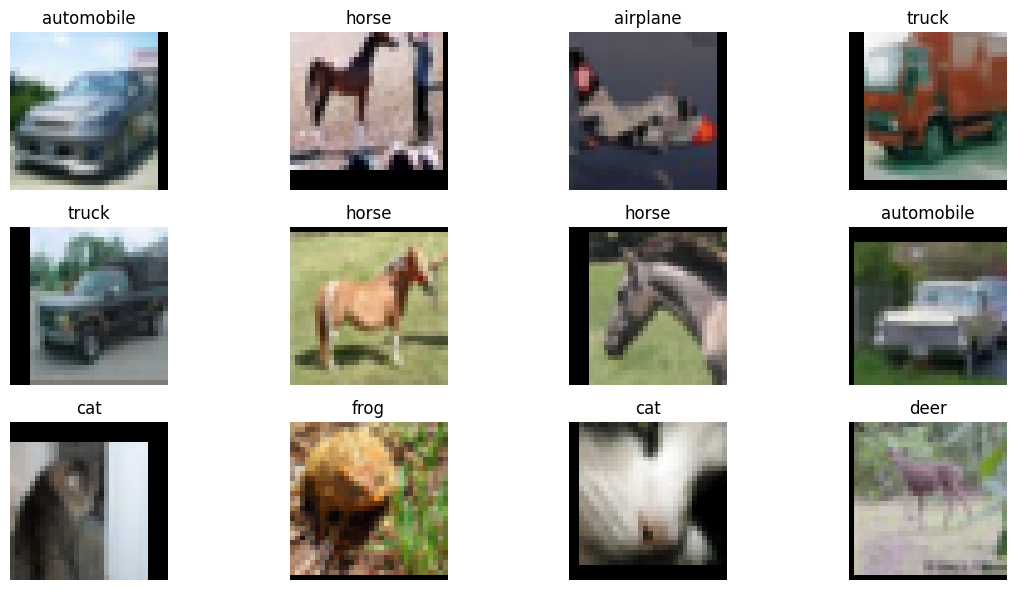

In [9]:
# Visualize a few CIFAR-10 training images
# CIFAR-10 normalization values used above
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(12):
    img = images[i].cpu() * std + mean      # unnormalize
    img = torch.clamp(img, 0, 1)
    img = img.permute(1, 2, 0).numpy()      # C,H,W -> H,W,C

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(train_data.classes[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# Quick sanity check: one forward pass before training
img, label = next(iter(train_loader))
img = img.to(device)
out = model(img)
print("One batch output shape:", out.shape)  # expected: [batch_size, 10]


def evaluate(model, data_loader, loss_fn):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for img, label in data_loader:
            img = img.to(device)
            label = label.to(device)

            out = model(img)
            loss = loss_fn(out, label)
            pred = out.argmax(dim=1)

            total_loss += loss.item()
            correct += pred.eq(label).sum().item()
            total += label.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    return avg_loss, accuracy


epochs = 15
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for img, label in tqdm(train_loader):
        img = img.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        out = model(img)
        loss = loss_fn(out, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pred = out.argmax(dim=1)
        correct += pred.eq(label).sum().item()
        total += label.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    test_loss, test_acc = evaluate(model, test_loader, loss_fn)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}% | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc * 100:.2f}%"
    )

One batch output shape: torch.Size([128, 10])


100%|██████████| 391/391 [04:09<00:00,  1.56it/s]


Epoch 1/15 | Train Loss: 1.7283 | Train Acc: 35.73% | Test Loss: 1.5543 | Test Acc: 42.93%


100%|██████████| 391/391 [04:07<00:00,  1.58it/s]


Epoch 2/15 | Train Loss: 1.4337 | Train Acc: 48.19% | Test Loss: 1.4232 | Test Acc: 48.40%


...

Epoch 13/15 | Train Loss: 0.8441 | Train Acc: 70.02% | Test Loss: 0.9096 | Test Acc: 68.05%


100%|██████████| 391/391 [04:06<00:00,  1.59it/s]


Epoch 14/15 | Train Loss: 0.8244 | Train Acc: 70.77% | Test Loss: 0.8796 | Test Acc: 69.21%


100%|██████████| 391/391 [04:06<00:00,  1.58it/s]


Epoch 15/15 | Train Loss: 0.7958 | Train Acc: 71.76% | Test Loss: 0.8644 | Test Acc: 69.16%


### Plot training and testing curves

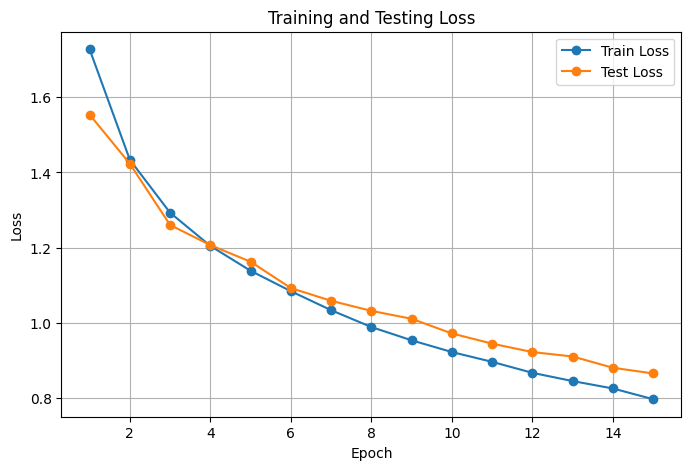

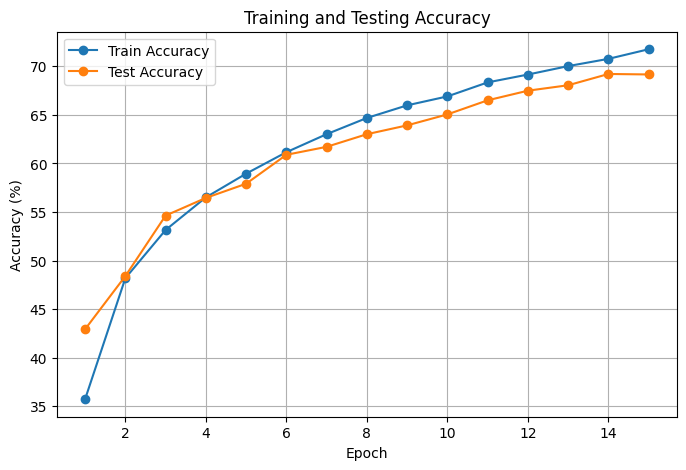

Final Train Loss: 0.7958
Final Train Accuracy: 71.76%
Final Test Loss: 0.8644
Final Test Accuracy: 69.16%


In [11]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, epochs + 1), test_losses, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Testing Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot accuracy curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), [acc * 100 for acc in train_accuracies], marker="o", label="Train Accuracy")
plt.plot(range(1, epochs + 1), [acc * 100 for acc in test_accuracies], marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Testing Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Final performance summary
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Train Accuracy: {train_accuracies[-1] * 100:.2f}%")
print(f"Final Test Loss: {test_losses[-1]:.4f}")
print(f"Final Test Accuracy: {test_accuracies[-1] * 100:.2f}%")